# Localizing answer dependence with residual patching

**Input:** the yellow-shirt GQA photo with a matched gray-image reference and unchanged question. **Models:** SmolVLM-500M and LLaVA-1.5-7B. **Tools:** actual Activation Patching and gradient Attribution Patching at the same residual/token coordinates.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


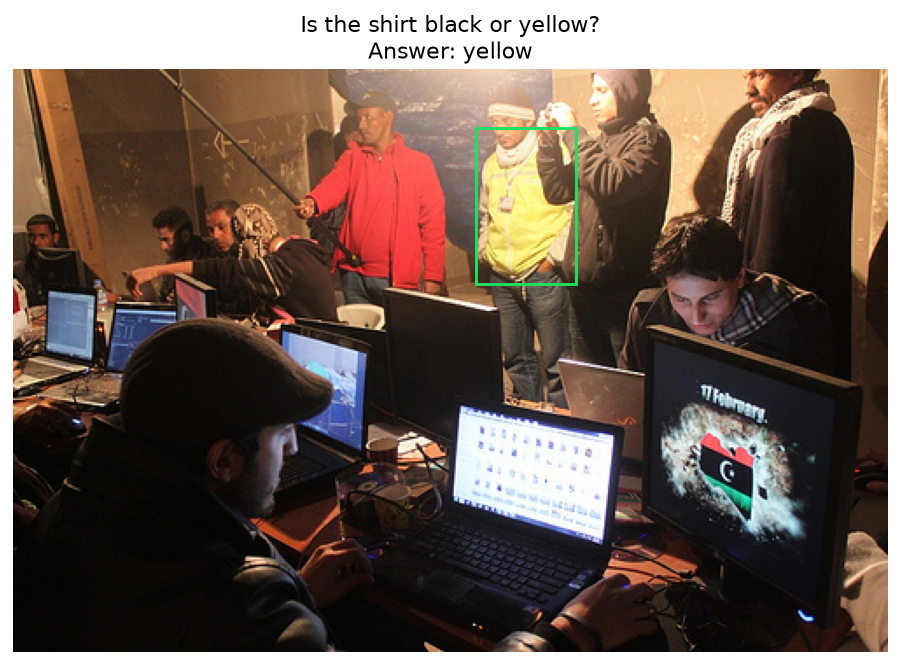

Intervention: replace only selected internal states by those from the gray-image reference.


In [2]:
records = [load_snapshot(f"activation_patching/{model}.json") for model in ("smolvlm","llava")]
sample = json.loads((ASSETS / "gqa_samples.json").read_text())[0]
ax = plot_input(load_image(sample["image_path"]),prompt=sample["question"],answer=sample["answer"],
                 bounding_boxes=[sample["bbox_xywh"]])
show_figure(ax.figure)
print("Intervention: replace only selected internal states by those from the gray-image reference.")

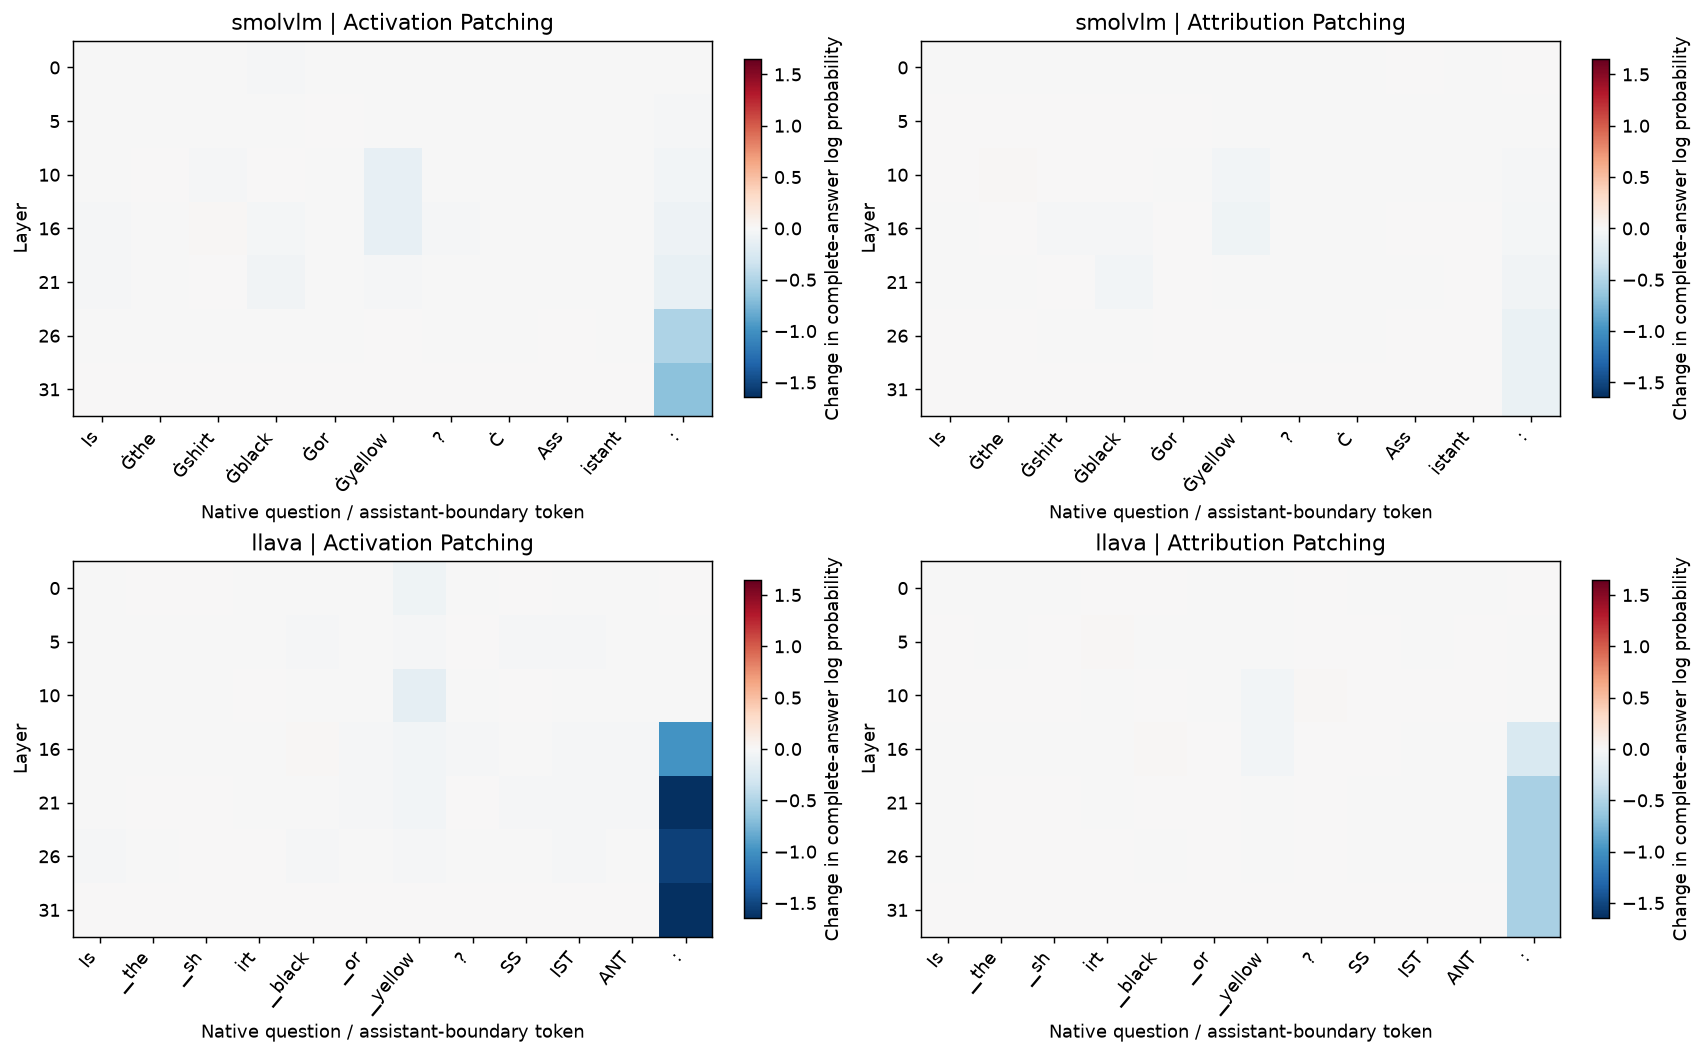

In [3]:
fig, axes = plt.subplots(len(records),2,figsize=(13,8),constrained_layout=True)
limit = max(np.abs(np.asarray(record["actual"]["text"])).max() for record in records)
for row,record in enumerate(records):
    measured_layers = record["actual_layers"]
    actual = np.asarray(record["actual"]["text"])
    estimated = np.asarray(record["approximate"]["text"])[measured_layers]
    for col,(name,values) in enumerate([("Activation Patching",actual),("Attribution Patching",estimated)]):
        ax = plot_causal_heatmap(values,ax=axes[row,col],layer_labels=measured_layers,
                                 column_labels=record["text_pieces"],vmin=-limit,vmax=limit,
                                 value_label="Change in complete-answer log probability",
                                 title=record["model"]["slug"]+" | "+name)
        ax.set_xlabel("Native question / assistant-boundary token")
show_figure(fig)

**How to read:** each cell replaces one native text-position residual at one layer. Negative changes reduce support for `Yellow`; positive changes increase it. Both panels use the seven genuinely measured layers and a shared signed scale; no missing activation intervention is interpolated. The attribution estimate uses the same source-minus-base direction but a local gradient. These visualizations localize sensitive computation; they do not claim that the freely generated answer flips at every cell.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [4]:
if RERUN:
    import torch
    from PIL import Image
    from demos.runtime import bind_model, gqa_case
    from demos.inputs import pad_square, append_answer
    from vlm_probing.metrics import SequenceLogProb
    probe,processor,device = bind_model("llava-hf/llava-1.5-7b-hf")
    base,scored,answer_mask,prediction_mask,masks,info = gqa_case(probe,processor,sample,ASSETS/"images")
    # The reference keeps native input IDs and geometry; only pixels change.
    original = load_image(sample["image_path"])
    gray = Image.new("RGB",original.size,(127,127,127))
    padded,_ = pad_square(gray,processor.image_processor.image_mean)
    reference_values = dict(processor(text=info["prompt"],images=padded,return_tensors="pt"))
    parameter = next(probe.model.parameters())
    reference_values = {key:value.to(device=device,dtype=parameter.dtype if value.is_floating_point() else value.dtype)
                        if isinstance(value,torch.Tensor) else value for key,value in reference_values.items()}
    from vlm_probing import ProbeInputs
    reference = ProbeInputs(reference_values,base.layout)
    answer_ids = processor.tokenizer.encode(sample["answer"].capitalize(),add_special_tokens=False)
    reference,_,_ = append_answer(reference,answer_ids)
    metric = SequenceLogProb(answer_mask)
    layers = [0,max(probe.spec.residuals)//2,max(probe.spec.residuals)]
    actual = probe.causal.patch(layers=layers,tokens=prediction_mask).run(scored,source=reference,
                                                                       metric=metric,alignment="position")
    estimated = probe.causal.attribute(layers=layers,tokens=prediction_mask).run(scored,source=reference,
                                                                               metric=metric,alignment="position")
    ax = plot_intervention_curves({"Activation Patching":actual.tensors["effect"].reshape(-1).numpy(),
                                   "Attribution Patching":estimated.tensors["estimated_effect"].reshape(-1).numpy()},
                                  x=layers,xlabel="Decoder layer",ylabel="Complete-answer log-probability change")
    show_figure(ax.figure)
else:
    print("Fresh residual interventions skipped.")

Fresh residual interventions skipped.


## Sources and interpretation

**Methods:** [Activation Patching / causal tracing](https://arxiv.org/abs/2202.05262), [Attribution Patching](https://www.neelnanda.io/mechanistic-interpretability/attribution-patching). **Data:** GQA question 07302654 / image 2341576, [author subset](https://github.com/FightingFighting/cross-modal-information-flow-in-MLLM/tree/main/datasets). The gray-image reference is a display experiment extension, not a dataset-average paper reproduction. Source and baseline prompts, layer coordinates, and measured score changes are retained in the snapshots.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.